In [3]:
# 1. Load dataset and convert date column into datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Load data
file_path = "stores_sales_forecasting.csv"
df = pd.read_csv(file_path, encoding='latin1')

# Convert Date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort by date
df = df.sort_values('Order Date')

# Set date as index
df.set_index('Order Date', inplace=True)

print(df.head())

            Row ID        Order ID  Ship Date       Ship Mode Customer ID  \
Order Date                                                                  
2014-01-06    7475  CA-2014-167199  1/10/2014  Standard Class    ME-17320   
2014-01-07    7661  CA-2014-105417  1/12/2014  Standard Class    VS-21820   
2014-01-10     867  CA-2014-149020  1/15/2014  Standard Class    AJ-10780   
2014-01-11     717  CA-2014-130092  1/14/2014     First Class    SV-20365   
2014-01-13    2979  CA-2014-109232  1/16/2014    Second Class    ND-18370   

                Customer Name      Segment        Country            City  \
Order Date                                                                  
2014-01-06      Maria Etezadi  Home Office  United States       Henderson   
2014-01-07   Vivek Sundaresam     Consumer  United States      Huntsville   
2014-01-10     Anthony Jacobs    Corporate  United States     Springfield   
2014-01-11        Seth Vernon     Consumer  United States           Dover  

In [4]:
# Monthly aggregation
monthly_sales = df['Sales'].resample('M').sum()

# Weekly aggregation (optional)
weekly_sales = df['Sales'].resample('W').sum()

/tmp/ipython-input-455795992.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Sales'].resample('M').sum()


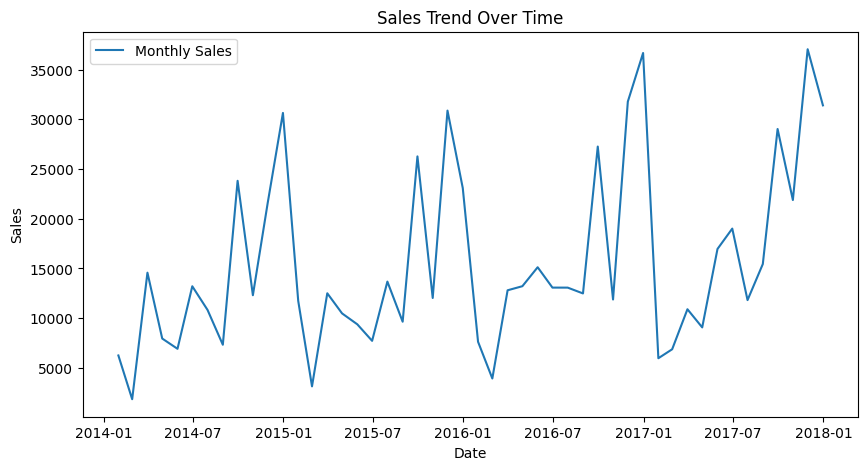

In [6]:
#Plot sales trend over time
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label='Monthly Sales')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

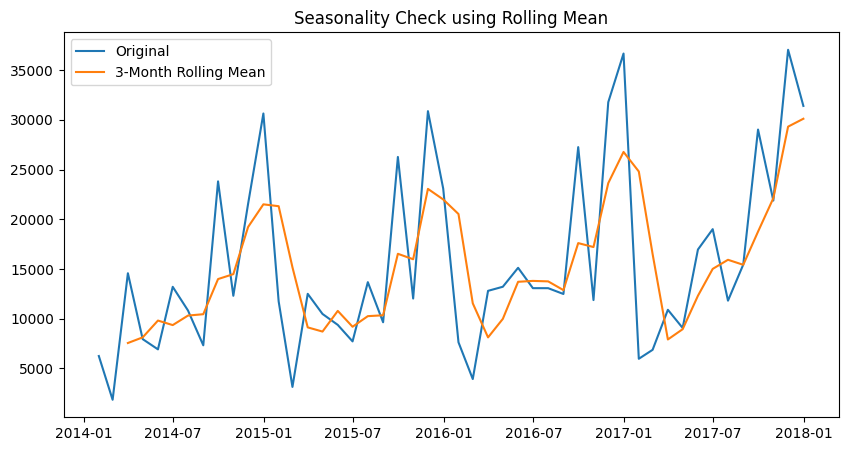

In [7]:
#Check seasonality using rolling mean
rolling_mean = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label='Original')
plt.plot(rolling_mean, label='3-Month Rolling Mean')
plt.title("Seasonality Check using Rolling Mean")
plt.legend()
plt.show()

In [8]:
#Split data into train/test by time
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 38
Test size: 10


In [9]:
#Forecasting Model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit model
model = ExponentialSmoothing(train, trend='add', seasonal=None)
model_fit = model.fit()

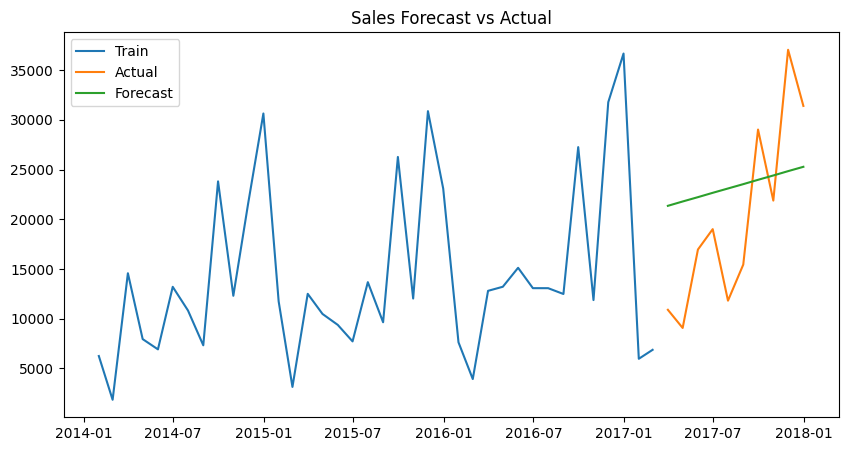

In [10]:
# Forecast for test period
forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast')
plt.title("Sales Forecast vs Actual")
plt.legend()
plt.show()

In [11]:
# MAE
mae = mean_absolute_error(test, forecast)

# MAPE
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("MAPE:", mape)

MAE: 7741.304448748939
MAPE: 51.609665536326844


In [12]:
# Create results dataframe
results = pd.DataFrame({
    'Actual': test,
    'Forecast': forecast
})

results.to_csv("sales_forecast_results.csv")

print("Forecast results exported successfully.")

Forecast results exported successfully.
